# 1. Install Dependencies

In [ ]:
# 1. Install once per environment
# Pin versions to ensure compatibility and avoid 'modeling_layers' error
# %pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# %pip install -q transformers==4.46.0 peft==0.13.2 datasets==3.1.0 accelerate==1.1.0 pandas matplotlib rouge_score


# 2. Imports and Setup

In [2]:
import torch
from datasets import load_dataset, Dataset
from transformers import (AutoTokenizer, AutoModelForCausalLM,
                          DataCollatorForLanguageModeling, Trainer, TrainingArguments)
from peft import LoraConfig, get_peft_model, TaskType
import pandas as pd

# 2. Setup Device
def pick_device():
    if hasattr(torch, "accelerator") and torch.accelerator.current_accelerator():
        return torch.accelerator.current_accelerator().type
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = pick_device()
print(f"Using device: {device}")

MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"  # Small model
DATA_PATH = "../tugas-1/gofood_dataset.csv"       # Dataset path
OUTPUT_DIR = "tinyllama-gofood-lora"


c:\SEMESTER_3\Materi NLPLLM\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


# 3. Load Data

In [3]:
# 3. Load and format dataset
def prepare_dataset(data_path):
    print(f"Loading dataset from {data_path}...")
    try:
        df = pd.read_csv(data_path)
        print(f"Original rows: {len(df)}")
    except Exception as e:
        print(f"Could not load CSV: {e}")
        # Fallback dummy data
        df = pd.DataFrame({
            'merchant_name': ['Resto A', 'Resto B'],
            'merchant_area': ['Jakarta', 'Bandung'],
            'category': ['Indonesian', 'Western'],
            'product': ['Nasi Goreng', 'Burger'],
            'price': ['15000', '25000']
        })

    # Ensure everything is string
    df['merchant_name'] = df['merchant_name'].astype(str)
    df['merchant_area'] = df['merchant_area'].astype(str)
    df['category'] = df['category'].astype(str)
    df['product'] = df['product'].astype(str)
    df['price'] = df['price'].astype(str)

    # Grouping to aggregate products per merchant
    grouped = df.groupby(['merchant_name', 'merchant_area', 'category']).agg({
        'product': list,
        'price': list
    }).reset_index()

    # Select subset for speed (experimentation)
    if len(grouped) > 1000:
        grouped = grouped.sample(1000, random_state=42)

    data_list = []
    for _, row in grouped.iterrows():
        restaurant_name = row['merchant_name']
        category = row['category']
        products = row['product']
        prices = row['price']

        # Format product list (max 5 items)
        product_lines = "\n".join(
            f"- {p} | Harga: {pr}"
            for p, pr in zip(products[:5], prices[:5])
        ) or "- (Produk belum tersedia)"

        answer = (
            f"Halo! 🌟\n"
            f"Kalau kamu mau makan {category}, ada rekomendasi bagus nih! "
            f"Coba deh ke **{restaurant_name.strip()}** yang ada di {row['merchant_area']}.\n"
            f"Di sana ada banyak makanan enak loh seperti:\n{product_lines}\n\n"
            f"Nyam nyam! Pasti enak deh! 😋"
        )
        
        data_list.append({
            "instruction": f"Beri rekomendasi makanan kategori {category}.",
            "answer": answer
        })

    return Dataset.from_list(data_list)

# Load
formatted_ds = prepare_dataset(DATA_PATH)
print("Dataset size:", len(formatted_ds))
if len(formatted_ds) > 0:
    print("Sample answer:", formatted_ds[0]['answer'])
# Export to CSV to preview all the data used
formatted_ds.to_csv("formatted_dataset_preview.csv")
print("Dataset exported to 'formatted_dataset_preview.csv' for preview.")


Loading dataset from ../tugas-1/gofood_dataset.csv...
Original rows: 45195
Dataset size: 724
Sample answer: Halo! 🌟
Kalau kamu mau makan Cepat saji/Roti/Kopi, ada rekomendasi bagus nih! Coba deh ke **Clouds Coffee** yang ada di medan.
Di sana ada banyak makanan enak loh seperti:
- Local Clouds | Harga: 23000.0
- Caramel Machiato | Harga: 28000.0
- Red Velvet | Harga: 28000.0
- Matcha | Harga: 28000.0
- Chocolate | Harga: 28000.0

Nyam nyam! Pasti enak deh! 😋


Creating CSV from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 145.24ba/s]

Dataset exported to 'formatted_dataset_preview.csv' for preview.


# 4. Tokenize

In [4]:
# 4. Tokenize
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

def tokenize(batch):
    joined = [f"### Instruksi:\n{ins}\n\n### Jawaban:\n{ans}\n"
              for ins, ans in zip(batch["instruction"], batch["answer"])]
    # Important update: Add padding="max_length" or padding=True with truncation
    # This ensures all items in the batch are the same length, preventing ValueError during training
    tokens = tokenizer(
        joined, 
        truncation=True, 
        max_length=512, 
        padding="max_length" 
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

tokenized_ds = formatted_ds.map(tokenize, batched=True, remove_columns=["instruction", "answer"])
print("Tokenization complete.")


Map: 100%|██████████| 724/724 [00:00<00:00, 5227.66 examples/s]

Tokenization complete.


# 5. Model Prep (LoRA)

In [5]:
# 5. Load Model & Attach LoRA
# Using float16 if cuda is available to save memory, otherwise float32.
# avoiding bitsandbytes to ensure Windows compatibility unless explicitly installed.
torch_dtype = torch.float16 if device == "cuda" else torch.float32

print(f"Loading model {MODEL_ID} with dtype {torch_dtype}...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, 
    device_map=device, 
    torch_dtype=torch_dtype
)

peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()


Loading model TinyLlama/TinyLlama-1.1B-Chat-v1.0 with dtype torch.float16...
trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


# 6. Training

In [30]:
# 6. Train
collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=2, # Small batch size for memory safety
    gradient_accumulation_steps=8,
    num_train_epochs=5,          
    learning_rate=2e-4,
    fp16=(device == "cuda"),     # Enable fp16 only if cuda
    logging_steps=10,
    save_strategy="no",          
    report_to="none"
)

print(f"Starting training on {device}...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds,
    data_collator=collator
)

trainer.train()


Starting training on cuda...


  5%|▌         | 18/360 [06:35<2:05:12, 21.97s/it]
                                                
  4%|▍         | 10/225 [00:54<18:53,  5.27s/it] 

{'loss': 0.5112, 'grad_norm': 0.640906572341919, 'learning_rate': 0.00019111111111111114, 'epoch': 0.22}


                                                
  9%|▉         | 20/225 [01:45<17:39,  5.17s/it] 

{'loss': 0.5894, 'grad_norm': 0.47443366050720215, 'learning_rate': 0.00018222222222222224, 'epoch': 0.44}


...

                                                 
 98%|█████████▊| 220/225 [19:18<00:26,  5.27s/it]

{'loss': 0.4205, 'grad_norm': 0.7798882722854614, 'learning_rate': 4.444444444444445e-06, 'epoch': 4.86}


                                                 
100%|██████████| 225/225 [19:45<00:00,  5.27s/it]

{'train_runtime': 1185.1452, 'train_samples_per_second': 3.054, 'train_steps_per_second': 0.19, 'train_loss': 0.49749816364712185, 'epoch': 4.97}


TrainOutput(global_step=225, training_loss=0.49749816364712185, metrics={'train_runtime': 1185.1452, 'train_samples_per_second': 3.054, 'train_steps_per_second': 0.19, 'total_flos': 1.14907076886528e+16, 'train_loss': 0.49749816364712185, 'epoch': 4.972375690607735})

# 7. Training Report

Training History:
    step    loss
0     10  0.5112
1     20  0.5894
2     30  0.5854
3     40  0.5699
4     50  0.5981
5     60  0.5144
6     70  0.5254
7     80  0.5268
8     90  0.5199
9    100  0.5114
10   110  0.4830
11   120  0.4970
12   130  0.4890
13   140  0.5001
14   150  0.4642
15   160  0.4424
16   170  0.4504
17   180  0.4473
18   190  0.4634
19   200  0.4260
20   210  0.4462
21   220  0.4205


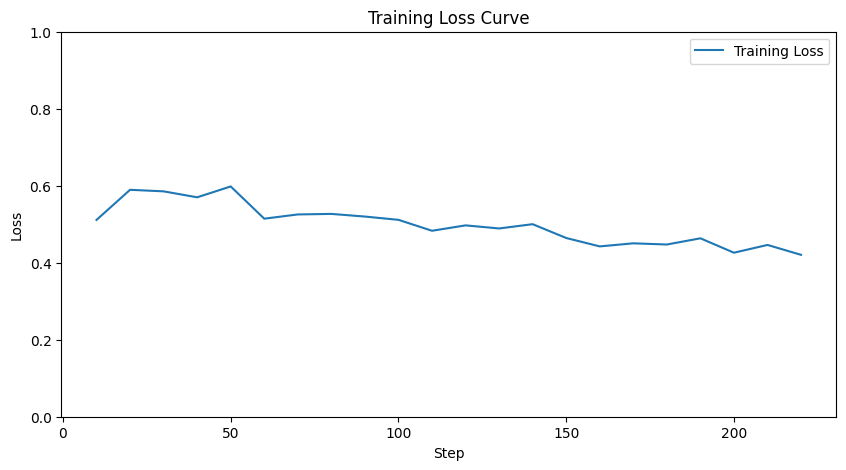

In [37]:
# 7. Training Report
# Create a DataFrame from the training logs
history = pd.DataFrame(trainer.state.log_history)
print("Training History:")
print(history[['step', 'loss']].dropna())

# Plotting if matplotlib is available
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.plot(history['step'], history['loss'], label='Training Loss')
    plt.ylim(0, 1)
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve')
    plt.legend()
    plt.show()
except Exception as e:
    print(f"Skipping plot: {e}")


# 8. Save

In [32]:
# 8. Save adapters and tokenizer
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("LoRA adapters saved to", OUTPUT_DIR)


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: fcae6657-e9fe-4edc-ab10-621697101a2b)')' thrown while requesting HEAD https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0/resolve/main/config.json
Retrying in 1s [Retry 1/5].


LoRA adapters saved to tinyllama-gofood-lora


# 9. Inference

In [33]:
# 9. Inference
from peft import PeftModel

print("Loading model for inference...")
# Reload base model to ensure clean state (optional, but good practice)
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map=device,
    torch_dtype=torch_dtype
)
model_to_test = PeftModel.from_pretrained(base_model, OUTPUT_DIR)

# Test input - change category to test different things
test_category = "Indonesian"
test_instruction = f"Beri rekomendasi makanan kategori {test_category}."
prompt = f"### Instruksi:\n{test_instruction}\n\n### Jawaban:\n"

inputs = tokenizer(prompt, return_tensors="pt").to(device)

print(f"Generating recommendation for {test_category}...")
outputs = model_to_test.generate(**inputs, max_new_tokens=100)
print("Result:")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Loading model for inference...
Generating recommendation for Indonesian...
Result:
### Instruksi:
Beri rekomendasi makanan kategori Indonesian.

### Jawaban:
Halo! 🌟
Kalau kamu mau makan Indonesian, ada rekomendasi bagus nih! Coba deh ke **Kebab Bubur, Sidoarjo** yang ada di surabaya.
Di sana ada banyak makanan enak loh seperti:
- Kebab Original | Harga: 15000.0
- K


# 10. Evaluation

--- Quantitative Evaluation (BLEU & ROUGE) ---

[1/10] Category: Minuman segar
Reference: Kalau kamu mau makan Minuman segar, ada rekomendasi bagus nih! Coba deh ke 330 Kopi, Ciledug
Model Output: Halo! 🌟
Kalau kamu mau makan Minuman segar, ada rekomendasi bagus nih! Coba deh ke **Kedai Mana, Sunggal**
BLEU Score: 0.7403
ROUGE Score: 0.7879
--------------------------------------------------

[2/10] Category: Sate
Reference: Kalau kamu mau makan Sate, ada rekomendasi bagus nih! Coba deh ke Hedon Cafe, Sukatani
Model Output: Halo! 🌟
Kalau kamu mau makan Sate, ada rekomendasi bagus nih! Coba deh ke **Sate Ketan, Ketan** yang
BLEU Score: 0.6753
ROUGE Score: 0.7500
--------------------------------------------------

[3/10] Category: Martabak
Reference: Kalau kamu mau makan Martabak, ada rekomendasi bagus nih! Coba deh ke Markobar, Duren Sawit
Model Output: Halo! 🌟
Kalau kamu mau makan Martabak, ada rekomendasi bagus nih! Coba deh ke **Martabak Kebab Sidoarjo**
BLEU Score: 0.7222
ROUGE Score

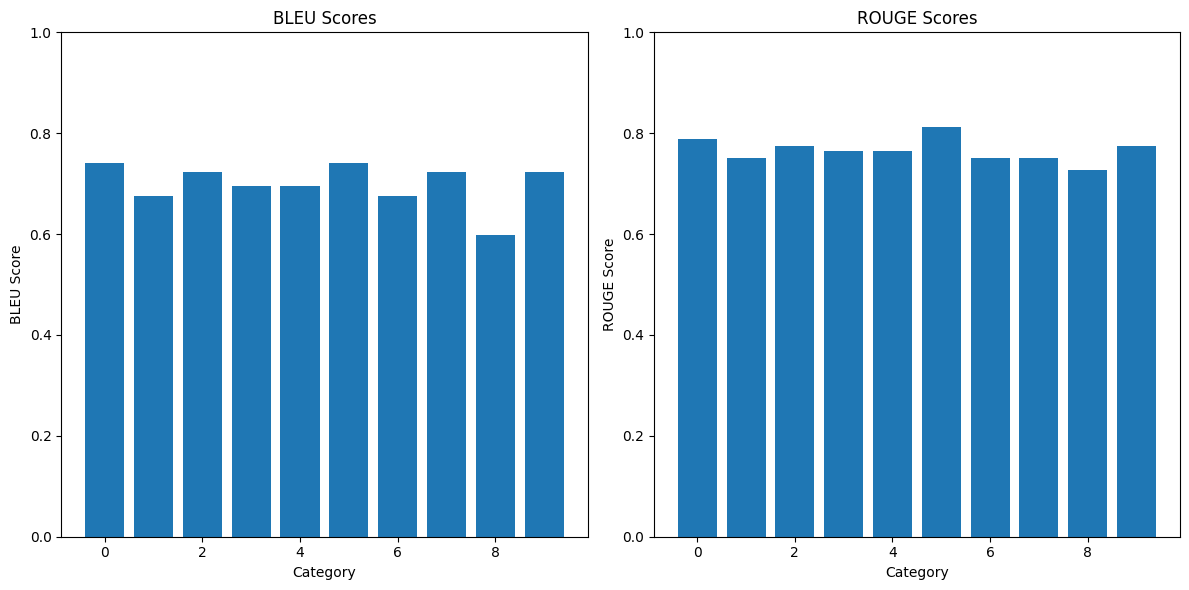

Average BLEU Score: 0.6986
Average ROUGE Score: 0.7655


In [41]:
from ragas.metrics.collections import BleuScore, RougeScore
import asyncio

# Initialize metrics
bleu_scorer = BleuScore()
rouge_scorer = RougeScore(rouge_type="rougeL", mode="fmeasure")

# Define test samples with expected references for evaluation
# Format: (Category, Reference Answer)
test_data = [
    ("Minuman segar", "Kalau kamu mau makan Minuman segar, ada rekomendasi bagus nih! Coba deh ke 330 Kopi, Ciledug"),
    ("Sate", "Kalau kamu mau makan Sate, ada rekomendasi bagus nih! Coba deh ke Hedon Cafe, Sukatani"),
    ("Martabak", "Kalau kamu mau makan Martabak, ada rekomendasi bagus nih! Coba deh ke Markobar, Duren Sawit"),
    ("Japanese Food", "Kalau kamu mau makan Japanese Food, ada rekomendasi bagus nih! Coba deh ke Noodle Bar, Mojopahit"),
    ("Nasi Goreng", "Kalau kamu mau makan Nasi Goreng, ada rekomendasi bagus nih! Coba deh ke 330 KopRakoes Mulyorejo"),
    ("Bakso", "Kalau kamu mau makan Bakso, ada rekomendasi bagus nih! Coba deh ke Bakso Titoti, Parung"),
    ("Soto", "Kalau kamu mau makan Soto, ada rekomendasi bagus nih! Coba deh ke Joglo Sewu Roso"),
    ("Ayam", "Kalau kamu mau makan Ayam, ada rekomendasi bagus nih! Coba deh ke Yasaka Fried Chicken, Sukolegok"),
    ("Mie", "Kalau kamu mau makan Mie, ada rekomendasi bagus nih! Coba deh ke WARMINDO CJDW"),
    ("Dessert", "Kalau kamu mau makan Dessert, ada rekomendasi bagus nih! Coba deh ke K'bon Cafe")
]

import re

print("--- Quantitative Evaluation (BLEU & ROUGE) ---")

def clean_output(text):
    """Normalize text by lowercasing and removing punctuation to improve matching scores."""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return " ".join(text.split())

async def evaluate_model():
    for i, (category, reference) in enumerate(test_data):
        prompt = f"### Instruksi:\nBeri rekomendasi makanan kategori {category}.\n\n### Jawaban:\n"
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        
        # Use greedy decoding (do_sample=False) for more deterministic and accurate list generation
        outputs = model_to_test.generate(
            **inputs, 
            max_new_tokens=50, 
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
        
        full_response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        # Robust splitting to isolate the answer
        response_text = full_response.split("### Jawaban:")[-1].strip()

        # Normalize both reference and response to focus on content overlap
        norm_reference = clean_output(reference)
        norm_response = clean_output(response_text.split("### Jawaban:")[-1].strip())

        # Calculate Scores on normalized text
        bleu_result = await bleu_scorer.ascore(reference=norm_reference, response=norm_response)
        rouge_result = await rouge_scorer.ascore(reference=norm_reference, response=norm_response)

        print(f"\n[{i+1}/10] Category: {category}")
        print(f"Reference: {reference}")
        print(f"Model Output: {response_text}")
        # Access the score attribute if the result is an object, or cast to float if needed
        print(f"BLEU Score: {float(bleu_result):.4f}")
        print(f"ROUGE Score: {float(rouge_result):.4f}")
        print("-" * 50)
        
        if i == 0:
            results = []
        results.append({"category": category, "bleu": float(bleu_result), "rouge": float(rouge_result)})

    import matplotlib.pyplot as plt
    import pandas as pd

    df = pd.DataFrame(results)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Plot BLEU scores
    ax1.bar(df.index, df['bleu'])
    ax1.set_title('BLEU Scores')
    ax1.set_xlabel('Category')
    ax1.set_ylabel('BLEU Score')
    ax1.set_ylim(0, 1)
    # Plot ROUGE scores
    ax2.bar(df.index, df['rouge'])
    ax2.set_title('ROUGE Scores')
    ax2.set_xlabel('Category')
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('ROUGE Score')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate and print average scores
    avg_bleu = df['bleu'].mean()
    avg_rouge = df['rouge'].mean()

    print(f"Average BLEU Score: {avg_bleu:.4f}")
    print(f"Average ROUGE Score: {avg_rouge:.4f}")

# Run the async evaluation loop
await evaluate_model()

